# Multi-NER Menggunakan Deep Sequence Model

Notebook ini menggunakan 2 deep sequence model yaitu **IndoBERT, NusaBERT** :

1. **IndoBERT** — `indobenchmark/indobert-base-p1`
2. **NusaBERT** — `LazarusNLP/NusaBERT-base`

Notebook ini membangun **multi-Named entity classification pada level teks** untuk lima NER:

- `ORGANISASI`
- `PLATFORM`
- `AGE_GROUP`
- `POLICY`
- `DIGITAL_RISK`

# 1. Instalasi Library

In [1]:
# # Instalasi CPU agar tidak bergantung pada CUDA/NVIDIA dan untuk
# # menghindari konflik DLL dari instalasi PyTorch sebelumnya.

# import os
# import sys
# import subprocess

# os.environ["USE_TF"] = "0"
# os.environ["TRANSFORMERS_NO_TF"] = "1"
# os.environ["USE_TORCH"] = "1"
# os.environ["TOKENIZERS_PARALLELISM"] = "false"

# print("Python yang digunakan:", sys.executable)

# # Bersihkan paket PyTorch yang mungkin rusak atau versinya tidak cocok.
# subprocess.run(
#     [
#         sys.executable, "-m", "pip", "uninstall", "-y",
#         "torch", "torchvision", "torchaudio"
#     ],
#     check=False,
# )

# # Pasang PyTorch CPU.
# subprocess.check_call(
#     [
#         sys.executable, "-m", "pip", "install",
#         "--no-cache-dir", "--force-reinstall",
#         "torch==2.8.0",
#         "--index-url", "https://download.pytorch.org/whl/cpu",
#     ]
# )

# # Dependensi yang benar-benar dipakai notebook.
# subprocess.check_call(
#     [
#         sys.executable, "-m", "pip", "install",
#         "--no-cache-dir", "--upgrade",
#         "transformers>=4.46,<5",
#         "pandas",
#         "numpy",
#         "scikit-learn",
#         "matplotlib",
#         "iterative-stratification",
#         "sentencepiece",
#         "openpyxl",
#     ]
# )

# print("\nInstalasi selesai.")


# 2. Import Library dan Konfigurasi

In [2]:
import os

# Setel sebelum mengimpor transformers.
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TORCH"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc
import hashlib
import inspect
import json
import random
import re
import time
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers

from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    hamming_loss,
    jaccard_score,
    multilabel_confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
    set_seed,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

print("Python executable    :", __import__("sys").executable)
print("PyTorch version     :", torch.__version__)
print("Transformers version:", transformers.__version__)
print("CUDA tersedia       :", torch.cuda.is_available())
print("Backend aktif       : PyTorch")


Python executable    : c:\Users\ACER\AppData\Local\Programs\Python\Python311\python.exe
PyTorch version     : 2.8.0+cpu
Transformers version: 4.57.6
CUDA tersedia       : False
Backend aktif       : PyTorch


In [3]:
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
set_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ENTITY_LABELS = [
    "ORGANISASI",
    "PLATFORM",
    "AGE_GROUP",
    "POLICY",
    "DIGITAL_RISK",
]

LABEL2ID = {label: index for index, label in enumerate(ENTITY_LABELS)}
ID2LABEL = {index: label for label, index in LABEL2ID.items()}

MODEL_NAMES = {
    "IndoBERT": "indobenchmark/indobert-base-p1",
    "NusaBERT": "LazarusNLP/NusaBERT-base",
}

MODEL_CMAPS = {
    "IndoBERT": "Blues",
    "NusaBERT": "Greens",
}

# Hyperparameter utama.
MAX_LENGTH = 128
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 5
PATIENCE = 2
WARMUP_RATIO = 0.10
GRADIENT_CLIP = 1.0
DEFAULT_THRESHOLD = 0.50
OPTIMIZE_THRESHOLD = True

EXPERIMENT_DIR = Path.cwd()
PROJECT_DIR = EXPERIMENT_DIR.parent
OUTPUT_DIR = PROJECT_DIR / "Outputs/Deep Sequence/Multi NER"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Device       :", DEVICE)
print("Label NER    :", ENTITY_LABELS)
print("Output folder:", OUTPUT_DIR.resolve())


Device       : cpu
Label NER    : ['ORGANISASI', 'PLATFORM', 'AGE_GROUP', 'POLICY', 'DIGITAL_RISK']
Output folder: D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Deep Sequence\Multi NER


# 3. Load Dataset

In [4]:
DATASET_FILENAME = "Dataset/Kelp2_dataset_anotasi_full_v2.jsonl"

DATA_PATH = Path.cwd().parent / DATASET_FILENAME

if DATA_PATH is None:
    searched = "\n".join(f"- {Path.resolve()}")
    raise FileNotFoundError(
        f"Dataset '{DATASET_FILENAME}' tidak ditemukan.\n"
    )

print("Dataset ditemukan:", DATA_PATH.resolve())


Dataset ditemukan: D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Dataset\Kelp2_dataset_anotasi_full_v2.jsonl


In [5]:
def load_jsonl(path):
    records = []

    with open(path, "r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"JSON tidak valid pada baris {line_number}: {exc}"
                ) from exc

    return records


records = load_jsonl(DATA_PATH)

print(f"Jumlah baris anotasi awal: {len(records):,}")
print("\nContoh data awal:")
display(pd.DataFrame(records[:2]))


Jumlah baris anotasi awal: 1,440

Contoh data awal:


,text,tokens,spans,_input_hash,_task_hash,options,_view_id,config,accept,answer,_timestamp,_annotator_id,_session_id
0,Mana nih woi wes kelewatan sudah 28 maret 2026,"[{'text': 'Mana', 'start': 0, 'end': 4, 'id': 0, 'ws': True}, {'text': 'nih', 'start': 5, 'end': 8, 'id': 1, 'ws': T...",[],-522954419,2021888820,"[{'id': 'PENOLAKAN_KEBIJAKAN', 'text': 'PENOLAKAN_KEBIJAKAN'}, {'id': 'DUKUNGAN_KEBIJAKAN', 'text': 'DUKUNGAN_KEBIJA...",blocks,{'choice_style': 'multiple'},[],accept,1776338823,apm2_genap2526-255313479,apm2_genap2526-255313479
1,Pemerintah udah keteraluan,"[{'text': 'Pemerintah', 'start': 0, 'end': 10, 'id': 0, 'ws': True}, {'text': 'udah', 'start': 11, 'end': 15, 'id': ...","[{'start': 0, 'end': 10, 'token_start': 0, 'token_end': 0, 'label': 'ORGANISASI'}]",-611415809,1993049520,"[{'id': 'PENOLAKAN_KEBIJAKAN', 'text': 'PENOLAKAN_KEBIJAKAN'}, {'id': 'DUKUNGAN_KEBIJAKAN', 'text': 'DUKUNGAN_KEBIJA...",blocks,{'choice_style': 'multiple'},[KRITIK_PEMERINTAHAN],accept,1776451254,apm2_genap2526-255313479,apm2_genap2526-255313479


# 4. Data Preparation

Apabila satu teks dianotasi oleh beberapa anotator:

- `union`: label dianggap ada apabila minimal satu anotator memberikan label tersebut.
- `intersection`: label dianggap ada hanya apabila seluruh anotator memberikan label tersebut.

Nilai target setiap teks berbentuk vektor biner sepanjang lima label, misalnya:

`[1, 0, 1, 0, 0]`

Artinya teks mengandung kelas `ORGANISASI` dan `AGE_GROUP`.


In [6]:
MERGE_STRATEGY = "union"


def clean_text(text):
    if text is None:
        return ""

    text = str(text)
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"@[A-Za-z0-9_]+", " USER ", text)
    text = re.sub(r"#([A-Za-z0-9_]+)", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def extract_entity_labels(record):
    """Mengambil hanya nama kelas dari spans, tanpa B-/I- dan tanpa posisi token."""
    return {
        str(span.get("label", "")).strip()
        for span in record.get("spans", [])
        if str(span.get("label", "")).strip() in ENTITY_LABELS
    }


def merge_label_sets(label_sets, strategy="union"):
    label_sets = list(label_sets)

    if not label_sets:
        return []

    if strategy == "union":
        merged = set().union(*label_sets)
    elif strategy == "intersection":
        merged = set.intersection(*label_sets)
    else:
        raise ValueError("MERGE_STRATEGY harus 'union' atau 'intersection'.")

    return [label for label in ENTITY_LABELS if label in merged]


def prepare_dataset(records, merge_strategy="union"):
    annotation_rows = []

    for index, record in enumerate(records):
        if record.get("answer") == "ignore":
            continue

        text = clean_text(record.get("text", ""))

        if not text:
            continue

        input_hash = record.get("_input_hash")
        group_id = str(input_hash) if input_hash is not None else text.casefold()

        annotation_rows.append(
            {
                "group_id": group_id,
                "text": text,
                "annotator": record.get("_annotator_id", f"annotator_{index}"),
                "entity_labels": extract_entity_labels(record),
            }
        )

    raw_df = pd.DataFrame(annotation_rows)

    if raw_df.empty:
        raise ValueError("Tidak ada data valid setelah proses pembersihan.")

    grouped_rows = []

    for group_id, group in raw_df.groupby("group_id", sort=False):
        grouped_rows.append(
            {
                "group_id": group_id,
                "text": group["text"].iloc[0],
                "entity_labels": merge_label_sets(
                    group["entity_labels"],
                    strategy=merge_strategy,
                ),
                "n_annotators": group["annotator"].nunique(),
            }
        )

    prepared_df = pd.DataFrame(grouped_rows)
    prepared_df = prepared_df.drop_duplicates(subset="text").reset_index(drop=True)

    for label in ENTITY_LABELS:
        prepared_df[label] = prepared_df["entity_labels"].apply(
            lambda labels: int(label in labels)
        )

    prepared_df["label_count"] = prepared_df[ENTITY_LABELS].sum(axis=1)

    return prepared_df


df = prepare_dataset(records, merge_strategy=MERGE_STRATEGY)

print(f"Jumlah teks unik setelah preparation: {len(df):,}")
display(df.head())


Jumlah teks unik setelah preparation: 720


,group_id,text,entity_labels,n_annotators,ORGANISASI,PLATFORM,AGE_GROUP,POLICY,DIGITAL_RISK,label_count
0,-522954419,Mana nih woi wes kelewatan sudah 28 maret 2026,[],2,0,0,0,0,0,0
1,-611415809,Pemerintah udah keteraluan,[ORGANISASI],2,1,0,0,0,0,1
2,957780750,Koruptor giliran judi ga dibasmi,[DIGITAL_RISK],2,0,0,0,0,1,1
3,-127654029,Nanggung banget 16 tahun tambahin 2 tahun kek jadinya 18 tahun kalo 16 tahun anak-anak belum matang dalam hidup wala...,[AGE_GROUP],2,0,0,1,0,0,1
4,104677311,Kapan diterapkan dan bagaimana langkah hukumnya,[POLICY],2,0,0,0,1,0,1


In [7]:
print("Teks kosong            :", int((df["text"].str.len() == 0).sum()))
print("Duplikat teks          :", int(df["text"].duplicated().sum()))
print("Teks tanpa entitas     :", int((df["label_count"] == 0).sum()))
print("Teks dengan >1 entitas :", int((df["label_count"] > 1).sum()))

label_distribution = (
    df[ENTITY_LABELS]
    .sum()
    .sort_values(ascending=False)
    .rename("jumlah_teks")
    .to_frame()
)

print("\nDistribusi lima label NER:")
display(label_distribution)


Teks kosong            : 0
Duplikat teks          : 0
Teks tanpa entitas     : 148
Teks dengan >1 entitas : 269

Distribusi lima label NER:


,jumlah_teks
PLATFORM,273
POLICY,237
AGE_GROUP,188
ORGANISASI,141
DIGITAL_RISK,138


# 5. Encoding Target dan Pembagian Data

In [8]:
mlb = MultiLabelBinarizer(classes=ENTITY_LABELS)

X = df["text"].reset_index(drop=True)
y = mlb.fit_transform(df["entity_labels"]).astype(np.float32)

print("Urutan target :", mlb.classes_.tolist())
print("Bentuk X      :", X.shape)
print("Bentuk y      :", y.shape)
print("Contoh target :", y[:5].astype(int).tolist())


Urutan target : ['ORGANISASI', 'PLATFORM', 'AGE_GROUP', 'POLICY', 'DIGITAL_RISK']
Bentuk X      : (720,)
Bentuk y      : (720, 5)
Contoh target : [[0, 0, 0, 0, 0], [1, 0, 0, 0, 0], [0, 0, 0, 0, 1], [0, 0, 1, 0, 0], [0, 0, 0, 1, 0]]


In [9]:
def multilabel_split_indices(y, test_size, random_state):
    indices = np.arange(len(y))

    try:
        from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

        splitter = MultilabelStratifiedShuffleSplit(
            n_splits=1,
            test_size=test_size,
            random_state=random_state,
        )
        train_idx, test_idx = next(splitter.split(indices, y))
        method = "MultilabelStratifiedShuffleSplit"

    except ImportError:
        train_idx, test_idx = train_test_split(
            indices,
            test_size=test_size,
            random_state=random_state,
            shuffle=True,
        )
        method = "train_test_split biasa"

    return train_idx, test_idx, method


# Test 20% .
train_val_idx, test_idx, split_method_1 = multilabel_split_indices(
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

# Sebagian data train dijadikan validation untuk early stopping.
train_rel_idx, val_rel_idx, split_method_2 = multilabel_split_indices(
    y[train_val_idx],
    test_size=0.125,  # 12.5% dari 80% = 10% seluruh data
    random_state=RANDOM_STATE,
)

train_idx = train_val_idx[train_rel_idx]
val_idx = train_val_idx[val_rel_idx]

X_train = X.iloc[train_idx].reset_index(drop=True)
X_val = X.iloc[val_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

print("Metode split 1     :", split_method_1)
print("Metode split 2     :", split_method_2)
print("Jumlah data train  :", len(X_train))
print("Jumlah data validasi:", len(X_val))
print("Jumlah data test   :", len(X_test))


Metode split 1     : MultilabelStratifiedShuffleSplit
Metode split 2     : MultilabelStratifiedShuffleSplit
Jumlah data train  : 504
Jumlah data validasi: 72
Jumlah data test   : 144


In [10]:
def split_distribution(name, labels):
    return pd.Series(
        labels.sum(axis=0).astype(int),
        index=ENTITY_LABELS,
        name=name,
    )

split_distribution_df = pd.concat(
    [
        split_distribution("Train", y_train),
        split_distribution("Validation", y_val),
        split_distribution("Test", y_test),
    ],
    axis=1,
)

print("Distribusi label pada setiap subset:")
display(split_distribution_df)


Distribusi label pada setiap subset:


,Train,Validation,Test
ORGANISASI,99,14,28
PLATFORM,191,27,55
AGE_GROUP,131,19,38
POLICY,166,24,47
DIGITAL_RISK,96,14,28


# 6. Dataset PyTorch dan Fungsi Umum

In [11]:
class MultiLabelTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts.tolist() if hasattr(texts, "tolist") else list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        item = {
            key: value[index]
            for key, value in self.encodings.items()
        }
        item["labels"] = self.labels[index]
        return item


def create_data_loaders(tokenizer):
    train_dataset = MultiLabelTextDataset(
        X_train, y_train, tokenizer, max_length=MAX_LENGTH
    )
    val_dataset = MultiLabelTextDataset(
        X_val, y_val, tokenizer, max_length=MAX_LENGTH
    )
    test_dataset = MultiLabelTextDataset(
        X_test, y_test, tokenizer, max_length=MAX_LENGTH
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=TRAIN_BATCH_SIZE,
        shuffle=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=EVAL_BATCH_SIZE,
        shuffle=False,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=EVAL_BATCH_SIZE,
        shuffle=False,
    )

    return train_loader, val_loader, test_loader


In [12]:
def probabilities_to_predictions(probabilities, threshold=0.50):
    return (np.asarray(probabilities) >= threshold).astype(int)


def calculate_multilabel_metrics(y_true, y_pred, model_name=None):
    metrics = {
        "subset_accuracy": accuracy_score(y_true, y_pred),
        "label_accuracy": 1.0 - hamming_loss(y_true, y_pred),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "precision_micro": precision_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "recall_micro": recall_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "f1_micro": f1_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "jaccard_samples": jaccard_score(
            y_true, y_pred, average="samples", zero_division=0
        ),
    }

    if model_name is not None:
        metrics = {"model": model_name, **metrics}

    return metrics


def find_best_global_threshold(y_true, probabilities):
    rows = []

    for threshold in np.arange(0.20, 0.81, 0.05):
        predictions = probabilities_to_predictions(probabilities, threshold)
        rows.append(
            {
                "threshold": round(float(threshold), 2),
                "f1_micro": f1_score(
                    y_true, predictions, average="micro", zero_division=0
                ),
                "f1_macro": f1_score(
                    y_true, predictions, average="macro", zero_division=0
                ),
            }
        )

    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.sort_values(
        ["f1_micro", "f1_macro"], ascending=False
    ).iloc[0]

    return float(best_row["threshold"]), threshold_df


In [13]:
@torch.no_grad()
def predict_probabilities(model, data_loader, device=DEVICE):
    model.eval()

    all_probabilities = []
    all_labels = []
    losses = []

    for batch in data_loader:
        labels = batch.pop("labels").to(device)
        inputs = {key: value.to(device) for key, value in batch.items()}

        outputs = model(**inputs, labels=labels)
        probabilities = torch.sigmoid(outputs.logits)

        losses.append(outputs.loss.item())
        all_probabilities.append(probabilities.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    return (
        np.vstack(all_probabilities),
        np.vstack(all_labels).astype(int),
        float(np.mean(losses)),
    )


def train_model(
    model,
    train_loader,
    val_loader,
    model_name,
    tokenizer,
    output_dir,
):
    model = model.to(DEVICE)

    optimizer = AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    total_steps = len(train_loader) * NUM_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    use_amp = DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    history = []
    best_val_f1 = -1.0
    epochs_without_improvement = 0

    print("=" * 80)
    print(f"{model_name} - MULTI-NER TRAINING")
    print("=" * 80)
    
    for epoch in range(1, NUM_EPOCHS + 1):
        start_time = time.time()
        model.train()
        train_losses = []

        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)

            labels = batch.pop("labels").to(DEVICE)
            inputs = {key: value.to(DEVICE) for key, value in batch.items()}

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=use_amp,
            ):
                outputs = model(**inputs, labels=labels)
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            train_losses.append(loss.item())

        val_probabilities, val_labels, val_loss = predict_probabilities(
            model, val_loader
        )
        val_predictions = probabilities_to_predictions(
            val_probabilities, DEFAULT_THRESHOLD
        )
        val_metrics = calculate_multilabel_metrics(val_labels, val_predictions)

        epoch_row = {
            "model": model_name,
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_loss": val_loss,
            "val_f1_micro": val_metrics["f1_micro"],
            "val_f1_macro": val_metrics["f1_macro"],
            "duration_seconds": time.time() - start_time,
        }
        history.append(epoch_row)

        print(
            f"[{model_name}] Epoch {epoch}/{NUM_EPOCHS} | "
            f"train_loss={epoch_row['train_loss']:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_f1_micro={val_metrics['f1_micro']:.4f}"
        )

        if val_metrics["f1_micro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_micro"]
            epochs_without_improvement = 0
            model.save_pretrained(output_dir)
            tokenizer.save_pretrained(output_dir)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping pada epoch {epoch}.")
            break
    
    print("=" * 80)
    print(f"{model_name} - TRAINING HIS")
    print("=" * 80)
    
    history_df = pd.DataFrame(history)

    best_model = AutoModelForSequenceClassification.from_pretrained(
        output_dir
    ).to(DEVICE)

    return best_model, history_df


In [14]:
def build_classification_report(model_name, y_true, y_pred):
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=ENTITY_LABELS,
        output_dict=True,
        zero_division=0,
    )

    report_df = pd.DataFrame(report_dict).T.reset_index()
    report_df = report_df.rename(columns={"index": "label"})
    report_df.insert(0, "model", model_name)

    return report_df


def build_confusion_dataframe(model_name, y_true, y_pred):
    matrices = multilabel_confusion_matrix(y_true, y_pred)
    rows = []

    for label, matrix in zip(ENTITY_LABELS, matrices):
        tn, fp, fn, tp = matrix.ravel()
        total = tn + fp + fn + tp

        rows.append(
            {
                "model": model_name,
                "label_ner": label,
                "true_negative": int(tn),
                "false_positive": int(fp),
                "false_negative": int(fn),
                "true_positive": int(tp),
                "total_data": int(total),
                "accuracy": (tp + tn) / total if total else 0.0,
                "precision": tp / (tp + fp) if (tp + fp) else 0.0,
                "recall": tp / (tp + fn) if (tp + fn) else 0.0,
                "f1_score": (
                    2 * tp / (2 * tp + fp + fn)
                    if (2 * tp + fp + fn)
                    else 0.0
                ),
            }
        )

    return pd.DataFrame(rows), matrices

def plot_confusion_matrix(
    y_true,
    y_pred,
    label_names,
    model_name,
    cmap="Blues"
):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    if y_true.shape != y_pred.shape:
        raise ValueError(
            f"Shape y_true {y_true.shape} dan "
            f"y_pred {y_pred.shape} harus sama."
        )

    if y_true.shape[1] != len(label_names):
        raise ValueError(
            "Jumlah kolom label tidak sesuai dengan label_names."
        )

    # Matrix label aktual × label prediksi
    confusion_matrix= y_true.T @ y_pred

    fig, ax = plt.subplots(figsize=(9, 7))

    image = ax.imshow(
        confusion_matrix,
        interpolation="nearest",
        cmap=cmap
    )

    plt.colorbar(image, ax=ax)

    ax.set_title(
        f"Confusion Matrix - {model_name}",
        fontsize=15,
        pad=12
    )
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("Actual Label", fontsize=11)

    ax.set_xticks(np.arange(len(label_names)))
    ax.set_yticks(np.arange(len(label_names)))

    ax.set_xticklabels(
        label_names,
        rotation=30,
        ha="right"
    )
    ax.set_yticklabels(label_names)

    threshold = (
        confusion_matrix.max() / 2
        if confusion_matrix.size > 0
        else 0
    )

    for row in range(confusion_matrix.shape[0]):
        for column in range(confusion_matrix.shape[1]):
            value = int(confusion_matrix[row, column])

            ax.text(
                column,
                row,
                value,
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
                fontsize=11
            )

    plt.tight_layout()
    plt.show()

    return confusion_matrix

def plot_multilabel_confusion(
    matrices,
    model_name,
    cmap="Blues",
):
    # Setiap label NER memiliki confusion matrix biner:
    # 0 = Tidak Terdeteksi dan 1 = Terdeteksi.
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(ENTITY_LABELS),
        figsize=(5 * len(ENTITY_LABELS), 4.5),
    )

    # Agar fungsi tetap berjalan apabila hanya ada satu label.
    if len(ENTITY_LABELS) == 1:
        axes = [axes]

    for axis, label, matrix in zip(
        axes,
        ENTITY_LABELS,
        matrices,
    ):
        display_matrix = ConfusionMatrixDisplay(
            confusion_matrix=matrix,
            display_labels=[
                "Tidak Terdeteksi",
                "Terdeteksi",
            ],
        )

        display_matrix.plot(
            ax=axis,
            cmap=cmap,
            values_format="d",
            colorbar=False,
        )

        axis.set_title(
            label,
            fontsize=12,
            fontweight="bold",
        )
        axis.set_xlabel("Prediksi")
        axis.set_ylabel("Aktual")

    fig.suptitle(
        f"Confusion Matrix Multi-NER – {model_name}",
        fontsize=16,
        fontweight="bold",
        y=1.03,
    )

    plt.tight_layout()
    plt.show()

def plot_training_history(history_df, model_name):
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
    plt.title(f"Training History - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# 7. Training

## IndoBERT

### Inisialisasi IndoBERT

In [15]:
INDOBERT_MODEL_ID = MODEL_NAMES["IndoBERT"]
INDOBERT_OUTPUT_DIR = OUTPUT_DIR / "IndoBERT"

indobert_tokenizer = AutoTokenizer.from_pretrained(
    INDOBERT_MODEL_ID,
    use_fast=True,
)

indobert_model = AutoModelForSequenceClassification.from_pretrained(
    INDOBERT_MODEL_ID,
    num_labels=len(ENTITY_LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    problem_type="multi_label_classification",
)

(
    indobert_train_loader,
    indobert_val_loader,
    indobert_test_loader,
) = create_data_loaders(indobert_tokenizer)

print("Model       :", INDOBERT_MODEL_ID)
print("Output model:", INDOBERT_OUTPUT_DIR.resolve())


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model       : indobenchmark/indobert-base-p1
Output model: D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Deep Sequence\Multi NER\IndoBERT


### Training IndoBERT

IndoBERT - MULTI-NER TRAINING
[IndoBERT] Epoch 1/5 | train_loss=0.5467 | val_loss=0.4157 | val_f1_micro=0.5772
[IndoBERT] Epoch 2/5 | train_loss=0.3249 | val_loss=0.2671 | val_f1_micro=0.8090
[IndoBERT] Epoch 3/5 | train_loss=0.1957 | val_loss=0.2103 | val_f1_micro=0.8557
[IndoBERT] Epoch 4/5 | train_loss=0.1332 | val_loss=0.1979 | val_f1_micro=0.8731
[IndoBERT] Epoch 5/5 | train_loss=0.1033 | val_loss=0.1957 | val_f1_micro=0.8660
IndoBERT - TRAINING HIS


,model,epoch,train_loss,val_loss,val_f1_micro,val_f1_macro,duration_seconds
0,IndoBERT,1,0.546680,0.415661,0.577181,0.554751,344.800820
1,IndoBERT,2,0.324909,0.267097,0.808989,0.809440,336.774021
2,IndoBERT,3,0.195731,0.210286,0.855670,0.868201,346.073915
3,IndoBERT,4,0.133181,0.197889,0.873096,0.883831,277.590744
4,IndoBERT,5,0.103327,0.195701,0.865979,0.875517,269.050711


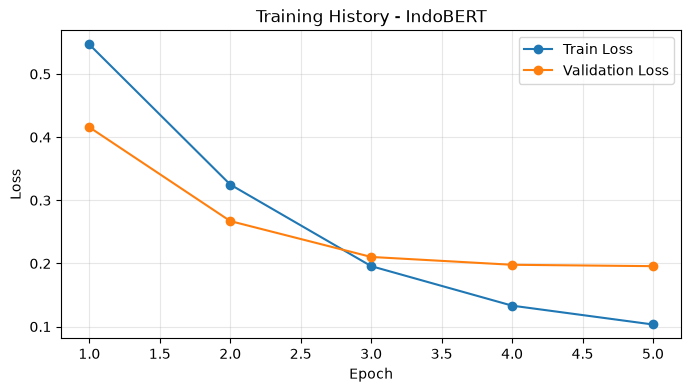

In [16]:
indobert_best_model, indobert_history = train_model(
    model=indobert_model,
    train_loader=indobert_train_loader,
    val_loader=indobert_val_loader,
    model_name="IndoBERT",
    tokenizer=indobert_tokenizer,
    output_dir=INDOBERT_OUTPUT_DIR,
)


display(indobert_history)
plot_training_history(indobert_history, "IndoBERT")


### Penentuan Threshold IndoBERT

In [17]:
(
    indobert_val_probabilities,
    indobert_val_labels,
    indobert_val_loss,
) = predict_probabilities(indobert_best_model, indobert_val_loader)

if OPTIMIZE_THRESHOLD:
    indobert_threshold, indobert_threshold_search = find_best_global_threshold(
        indobert_val_labels,
        indobert_val_probabilities,
    )
else:
    indobert_threshold = DEFAULT_THRESHOLD
    indobert_threshold_search = pd.DataFrame(
        [{"threshold": DEFAULT_THRESHOLD}]
    )

print("Threshold terbaik IndoBERT:", indobert_threshold)
display(indobert_threshold_search)


Threshold terbaik IndoBERT: 0.45


,threshold,f1_micro,f1_macro
0,0.20,0.835556,0.843776
1,0.25,0.838710,0.845574
2,0.30,0.853081,0.860020
3,0.35,0.868293,0.875463
4,0.40,0.872549,0.879479
5,0.45,0.881188,0.889655
6,0.50,0.873096,0.883831
7,0.55,0.873096,0.883831
8,0.60,0.863158,0.874017
9,0.65,0.867725,0.880454


### Classification Report IndoBERT

In [18]:
(
    indobert_test_probabilities,
    indobert_test_labels,
    indobert_test_loss,
) = predict_probabilities(indobert_best_model, indobert_test_loader)

indobert_test_predictions = probabilities_to_predictions(
    indobert_test_probabilities,
    indobert_threshold,
)

indobert_classification_report = build_classification_report(
    "IndoBERT",
    indobert_test_labels,
    indobert_test_predictions,
)

display(indobert_classification_report)


,model,label,precision,recall,f1-score,support
0,IndoBERT,ORGANISASI,0.928571,0.928571,0.928571,28.0
1,IndoBERT,PLATFORM,0.894737,0.927273,0.910714,55.0
2,IndoBERT,AGE_GROUP,0.857143,0.947368,0.900000,38.0
3,IndoBERT,POLICY,0.918367,0.957447,0.937500,47.0
4,IndoBERT,DIGITAL_RISK,0.880000,0.785714,0.830189,28.0
5,IndoBERT,micro avg,0.895522,0.918367,0.906801,196.0
6,IndoBERT,macro avg,0.895764,0.909275,0.901395,196.0
7,IndoBERT,weighted avg,0.895843,0.918367,0.906107,196.0
8,IndoBERT,samples avg,0.720255,0.720833,0.708113,196.0


### Evaluation Model IndoBERT

In [19]:
indobert_metrics = pd.DataFrame(
    [
        {
            **calculate_multilabel_metrics(
                indobert_test_labels,
                indobert_test_predictions,
                model_name="IndoBERT",
            ),
            "test_loss": indobert_test_loss,
            "threshold": indobert_threshold,
        }
    ]
)

display(indobert_metrics)


,model,subset_accuracy,label_accuracy,hamming_loss,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,f1_weighted,jaccard_samples,test_loss,threshold
0,IndoBERT,0.756944,0.948611,0.051389,0.895522,0.918367,0.906801,0.895764,0.909275,0.901395,0.906107,0.678356,0.170174,0.45


### Confusion Matrix IndoBERT

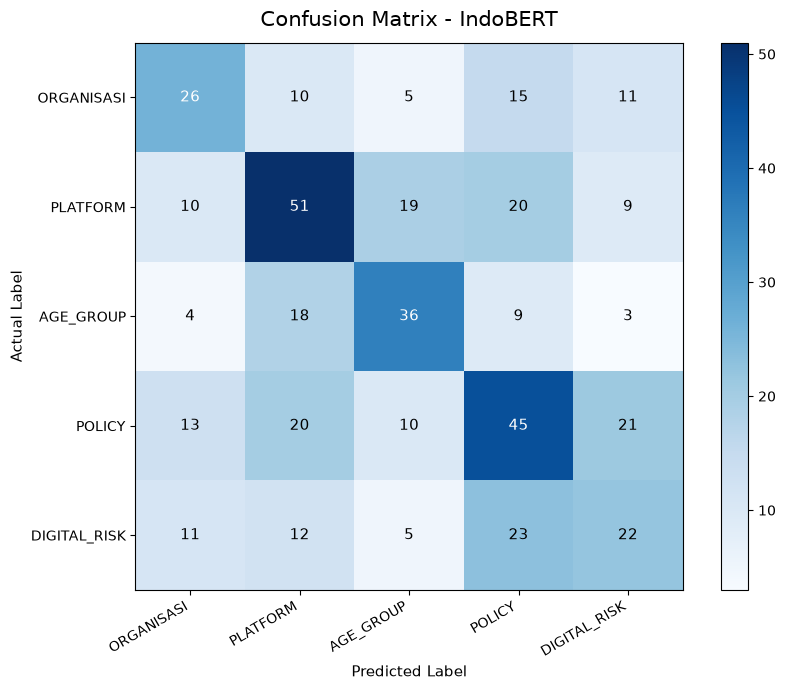

In [20]:
indobert_confusion_5x5 = plot_confusion_matrix(
    y_true=indobert_test_labels,
    y_pred=indobert_test_predictions,
    label_names=ENTITY_LABELS,
    model_name="IndoBERT",
    cmap="Blues"
)

In [21]:
(
    indobert_confusion_df,
    indobert_confusion_matrices,
) = build_confusion_dataframe(
    "IndoBERT",
    indobert_test_labels,
    indobert_test_predictions,
)

display(indobert_confusion_df)


,model,label_ner,true_negative,false_positive,false_negative,true_positive,total_data,accuracy,precision,recall,f1_score
0,IndoBERT,ORGANISASI,114,2,2,26,144,0.972222,0.928571,0.928571,0.928571
1,IndoBERT,PLATFORM,83,6,4,51,144,0.930556,0.894737,0.927273,0.910714
2,IndoBERT,AGE_GROUP,100,6,2,36,144,0.944444,0.857143,0.947368,0.900000
3,IndoBERT,POLICY,93,4,2,45,144,0.958333,0.918367,0.957447,0.937500
4,IndoBERT,DIGITAL_RISK,113,3,6,22,144,0.937500,0.880000,0.785714,0.830189


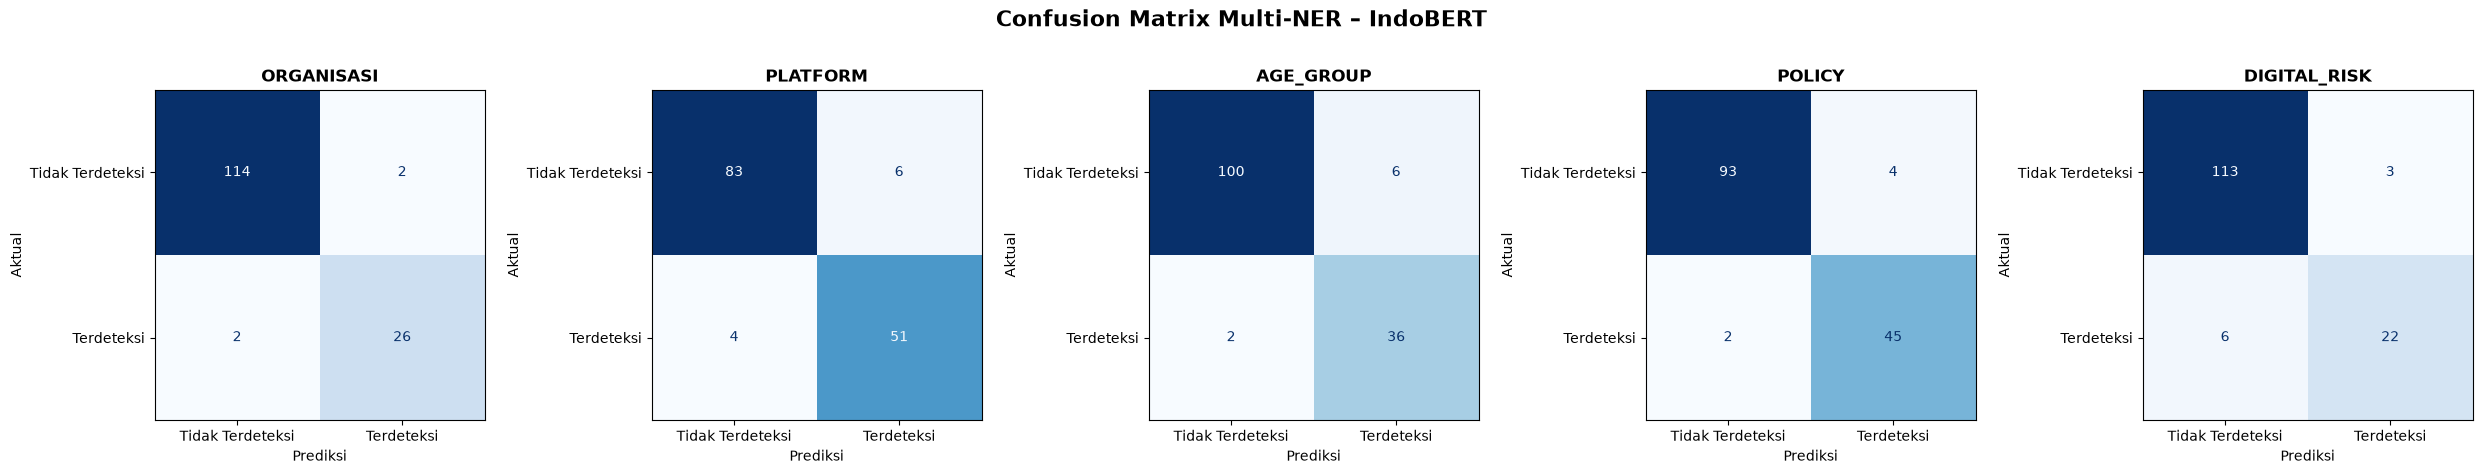

In [22]:
plot_multilabel_confusion(
    indobert_confusion_matrices,
    "IndoBERT",
    cmap=MODEL_CMAPS["IndoBERT"],
)


## NusaBERT

### Inisialisasi NusaBERT

In [23]:
NUSABERT_MODEL_ID = MODEL_NAMES["NusaBERT"]
NUSABERT_OUTPUT_DIR = OUTPUT_DIR / "NusaBERT"

nusabert_tokenizer = AutoTokenizer.from_pretrained(
    NUSABERT_MODEL_ID,
    use_fast=True,
)

nusabert_model = AutoModelForSequenceClassification.from_pretrained(
    NUSABERT_MODEL_ID,
    num_labels=len(ENTITY_LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    problem_type="multi_label_classification",
)

(
    nusabert_train_loader,
    nusabert_val_loader,
    nusabert_test_loader,
) = create_data_loaders(nusabert_tokenizer)

print("Model       :", NUSABERT_MODEL_ID)
print("Output model:", NUSABERT_OUTPUT_DIR.resolve())


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at LazarusNLP/NusaBERT-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model       : LazarusNLP/NusaBERT-base
Output model: D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Deep Sequence\Multi NER\NusaBERT


### Training NusaBERT

NusaBERT - MULTI-NER TRAINING
[NusaBERT] Epoch 1/5 | train_loss=0.6089 | val_loss=0.5298 | val_f1_micro=0.2087
[NusaBERT] Epoch 2/5 | train_loss=0.5270 | val_loss=0.4937 | val_f1_micro=0.3538
[NusaBERT] Epoch 3/5 | train_loss=0.4871 | val_loss=0.4705 | val_f1_micro=0.3824
[NusaBERT] Epoch 4/5 | train_loss=0.4494 | val_loss=0.4235 | val_f1_micro=0.4930
[NusaBERT] Epoch 5/5 | train_loss=0.4177 | val_loss=0.4046 | val_f1_micro=0.5479
NusaBERT - TRAINING HIS


,model,epoch,train_loss,val_loss,val_f1_micro,val_f1_macro,duration_seconds
0,NusaBERT,1,0.608886,0.529780,0.208696,0.141299,272.237238
1,NusaBERT,2,0.526960,0.493676,0.353846,0.254762,226.973222
2,NusaBERT,3,0.487088,0.470483,0.382353,0.288192,219.141230
3,NusaBERT,4,0.449367,0.423505,0.492958,0.381111,230.174589
4,NusaBERT,5,0.417663,0.404561,0.547945,0.439130,253.473578


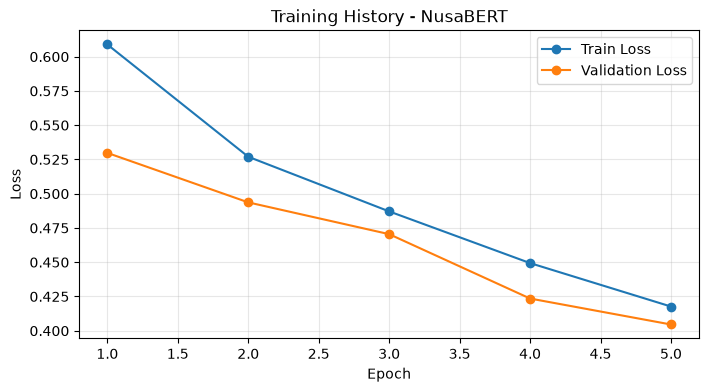

In [24]:
nusabert_best_model, nusabert_history = train_model(
    model=nusabert_model,
    train_loader=nusabert_train_loader,
    val_loader=nusabert_val_loader,
    model_name="NusaBERT",
    tokenizer=nusabert_tokenizer,
    output_dir=NUSABERT_OUTPUT_DIR,
)

display(nusabert_history)
plot_training_history(nusabert_history, "NusaBERT")


### Penentuan Threshold NusaBERT

In [25]:
(
    nusabert_val_probabilities,
    nusabert_val_labels,
    nusabert_val_loss,
) = predict_probabilities(nusabert_best_model, nusabert_val_loader)

if OPTIMIZE_THRESHOLD:
    nusabert_threshold, nusabert_threshold_search = find_best_global_threshold(
        nusabert_val_labels,
        nusabert_val_probabilities,
    )
else:
    nusabert_threshold = DEFAULT_THRESHOLD
    nusabert_threshold_search = pd.DataFrame(
        [{"threshold": DEFAULT_THRESHOLD}]
    )

print("Threshold terbaik NusaBERT:", nusabert_threshold)
display(nusabert_threshold_search)


Threshold terbaik NusaBERT: 0.25


,threshold,f1_micro,f1_macro
0,0.20,0.685714,0.676046
1,0.25,0.688679,0.664100
2,0.30,0.687179,0.654564
3,0.35,0.662983,0.603852
4,0.40,0.610778,0.539687
5,0.45,0.549020,0.470367
6,0.50,0.547945,0.439130
7,0.55,0.455882,0.351746
8,0.60,0.365079,0.271688
9,0.65,0.290598,0.205238


### Classification Report NusaBERT

In [26]:
(
    nusabert_test_probabilities,
    nusabert_test_labels,
    nusabert_test_loss,
) = predict_probabilities(nusabert_best_model, nusabert_test_loader)

nusabert_test_predictions = probabilities_to_predictions(
    nusabert_test_probabilities,
    nusabert_threshold,
)

nusabert_classification_report = build_classification_report(
    "NusaBERT",
    nusabert_test_labels,
    nusabert_test_predictions,
)

display(nusabert_classification_report)


,model,label,precision,recall,f1-score,support
0,NusaBERT,ORGANISASI,0.440000,0.392857,0.415094,28.0
1,NusaBERT,PLATFORM,0.574713,0.909091,0.704225,55.0
2,NusaBERT,AGE_GROUP,0.586207,0.894737,0.708333,38.0
3,NusaBERT,POLICY,0.532468,0.872340,0.661290,47.0
4,NusaBERT,DIGITAL_RISK,0.605263,0.821429,0.696970,28.0
5,NusaBERT,micro avg,0.557895,0.811224,0.661123,196.0
6,NusaBERT,macro avg,0.547730,0.778091,0.637183,196.0
7,NusaBERT,weighted avg,0.551931,0.811224,0.652385,196.0
8,NusaBERT,samples avg,0.395949,0.596644,0.456487,196.0


### Evaluation Model NusaBERT

In [27]:
nusabert_metrics = pd.DataFrame(
    [
        {
            **calculate_multilabel_metrics(
                nusabert_test_labels,
                nusabert_test_predictions,
                model_name="NusaBERT",
            ),
            "test_loss": nusabert_test_loss,
            "threshold": nusabert_threshold,
        }
    ]
)

display(nusabert_metrics)


,model,subset_accuracy,label_accuracy,hamming_loss,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,f1_weighted,jaccard_samples,test_loss,threshold
0,NusaBERT,0.277778,0.773611,0.226389,0.557895,0.811224,0.661123,0.54773,0.778091,0.637183,0.652385,0.377778,0.399167,0.25


### Confusion Matrix NusaBERT

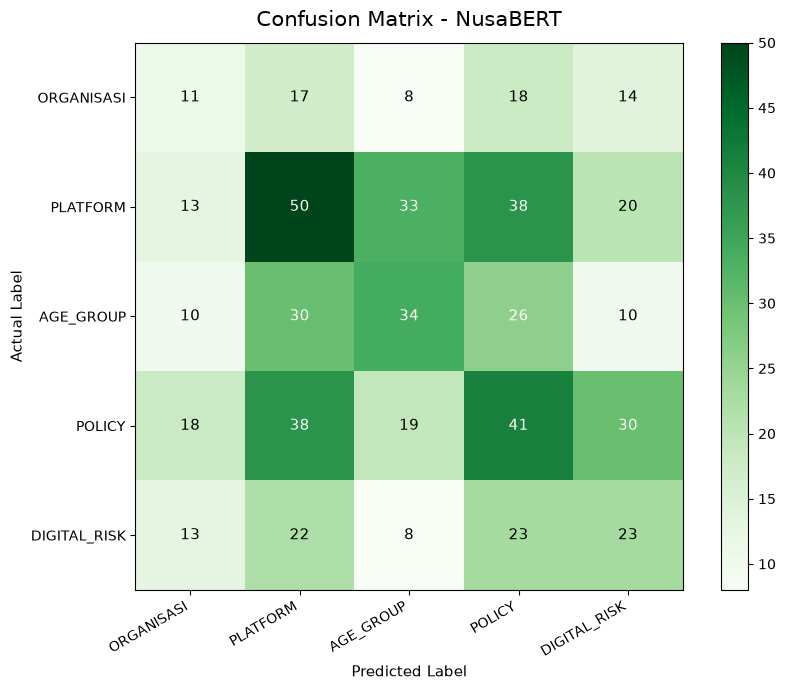

In [28]:
nusabert_confusion_5x5 = plot_confusion_matrix(
    y_true=nusabert_test_labels,
    y_pred=nusabert_test_predictions,
    label_names=ENTITY_LABELS,
    model_name="NusaBERT",
    cmap="Greens"
)

In [29]:
(
    nusabert_confusion_df,
    nusabert_confusion_matrices,
) = build_confusion_dataframe(
    "NusaBERT",
    nusabert_test_labels,
    nusabert_test_predictions,
)

,model,label_ner,true_negative,false_positive,false_negative,true_positive,total_data,accuracy,precision,recall,f1_score
0,NusaBERT,ORGANISASI,102,14,17,11,144,0.784722,0.440000,0.392857,0.415094
1,NusaBERT,PLATFORM,52,37,5,50,144,0.708333,0.574713,0.909091,0.704225
2,NusaBERT,AGE_GROUP,82,24,4,34,144,0.805556,0.586207,0.894737,0.708333
3,NusaBERT,POLICY,61,36,6,41,144,0.708333,0.532468,0.872340,0.661290
4,NusaBERT,DIGITAL_RISK,101,15,5,23,144,0.861111,0.605263,0.821429,0.696970


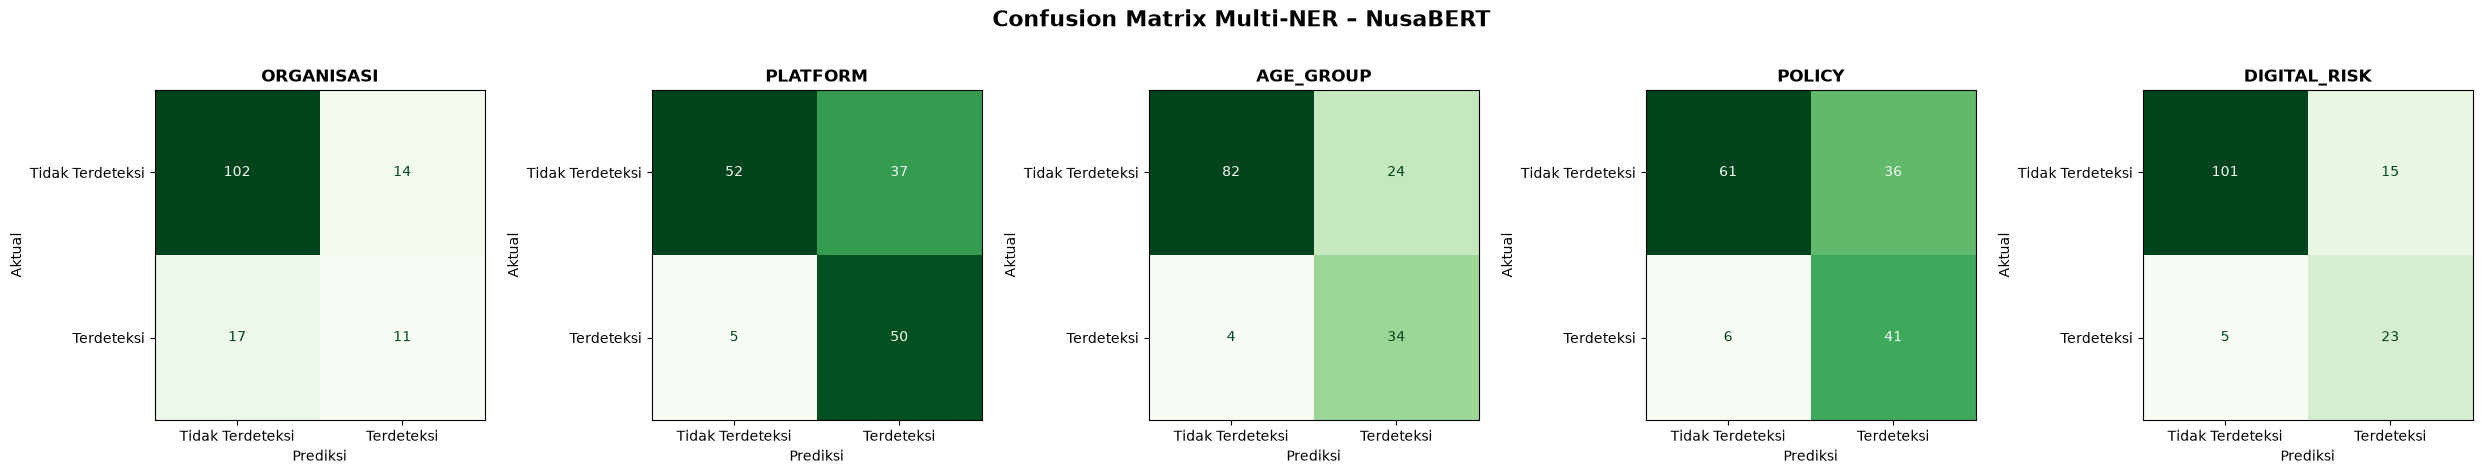

In [30]:
display(nusabert_confusion_df)
plot_multilabel_confusion(
    nusabert_confusion_matrices,
    "NusaBERT",
    cmap=MODEL_CMAPS["NusaBERT"],
)

# 8. Ringkasan Perbandingan IndoBERT dan NusaBERT

In [31]:
evaluation_summary_df = pd.concat(
    [
        indobert_metrics,
        nusabert_metrics,
    ],
    ignore_index=True,
).sort_values(
    by=["f1_micro", "hamming_loss"],
    ascending=[False, True],
).reset_index(drop=True)

print("Perbandingan metrik pada data test:")
display(evaluation_summary_df)

best_model_name = evaluation_summary_df.iloc[0]["model"]

print(
    "\nModel terbaik berdasarkan F1-micro tertinggi, "
    "kemudian Hamming Loss terendah:"
)
print(best_model_name)


Perbandingan metrik pada data test:


,model,subset_accuracy,label_accuracy,hamming_loss,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,f1_weighted,jaccard_samples,test_loss,threshold
0,IndoBERT,0.756944,0.948611,0.051389,0.895522,0.918367,0.906801,0.895764,0.909275,0.901395,0.906107,0.678356,0.170174,0.45
1,NusaBERT,0.277778,0.773611,0.226389,0.557895,0.811224,0.661123,0.547730,0.778091,0.637183,0.652385,0.377778,0.399167,0.25



Model terbaik berdasarkan F1-micro tertinggi, kemudian Hamming Loss terendah:
IndoBERT


# 9. Simpan Hasil Evaluasi

In [32]:
all_metrics_df = pd.concat(
    [indobert_metrics, nusabert_metrics],
    ignore_index=True,
)

all_reports_df = pd.concat(
    [
        indobert_classification_report,
        nusabert_classification_report,
    ],
    ignore_index=True,
)

all_confusion_df = pd.concat(
    [
        indobert_confusion_df,
        nusabert_confusion_df,
    ],
    ignore_index=True,
)

all_history_df = pd.concat(
    [
        indobert_history,
        nusabert_history,
    ],
    ignore_index=True,
)

all_thresholds_df = pd.concat(
    [
        indobert_threshold_search.assign(model="IndoBERT"),
        nusabert_threshold_search.assign(model="NusaBERT"),
    ],
    ignore_index=True,
)

EXCEL_RESULT_PATH = OUTPUT_DIR / "NER_evaluasi_deep_sequence.xlsx"

with pd.ExcelWriter(EXCEL_RESULT_PATH, engine="openpyxl") as writer:
    all_metrics_df.to_excel(writer, sheet_name="Metrics", index=False)
    all_reports_df.to_excel(writer, sheet_name="Classification_Report", index=False)
    all_confusion_df.to_excel(writer, sheet_name="Confusion_Matrix", index=False)
    all_history_df.to_excel(writer, sheet_name="Training_History", index=False)
    all_thresholds_df.to_excel(writer, sheet_name="Threshold_Search", index=False)

print("Excel berhasil disimpan:")
print(EXCEL_RESULT_PATH.resolve())


Excel berhasil disimpan:
D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Deep Sequence\Multi NER\NER_evaluasi_deep_sequence.xlsx


# 10. Prediksi Data Baru

In [33]:
data_baru = [
    "Kementerian Kesehatan meluncurkan Program Cek Kesehatan Gratis melalui aplikasi SATUSEHAT untuk kelompok remaja.",
    "WHO mengeluarkan kebijakan perlindungan kesehatan mental bagi anak dan remaja pengguna Instagram.",
    "Pemerintah Indonesia menjalankan Program Indonesia Sehat untuk kelompok usia lanjut melalui platform digital.",
    "TikTok menerapkan kebijakan pembatasan penggunaan aplikasi bagi pengguna berusia di bawah 18 tahun.",
    "UNICEF bekerja sama dengan Kementerian Pendidikan dalam program perlindungan anak di media sosial.",
]

print("Jumlah data baru:", len(data_baru))
for nomor, teks in enumerate(data_baru, start=1):
    print(f"{nomor}. {teks}")


Jumlah data baru: 5
1. Kementerian Kesehatan meluncurkan Program Cek Kesehatan Gratis melalui aplikasi SATUSEHAT untuk kelompok remaja.
2. WHO mengeluarkan kebijakan perlindungan kesehatan mental bagi anak dan remaja pengguna Instagram.
3. Pemerintah Indonesia menjalankan Program Indonesia Sehat untuk kelompok usia lanjut melalui platform digital.
4. TikTok menerapkan kebijakan pembatasan penggunaan aplikasi bagi pengguna berusia di bawah 18 tahun.
5. UNICEF bekerja sama dengan Kementerian Pendidikan dalam program perlindungan anak di media sosial.


In [34]:
@torch.no_grad()
def predict_new_texts(
    model,
    tokenizer,
    texts,
    threshold,
    batch_size=16,
):
    model.eval()
    model.to(DEVICE)

    probabilities_all = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start : start + batch_size]
        encoded = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        encoded = {key: value.to(DEVICE) for key, value in encoded.items()}

        logits = model(**encoded).logits
        probabilities = torch.sigmoid(logits).cpu().numpy()
        probabilities_all.append(probabilities)

    probabilities_all = np.vstack(probabilities_all)
    predictions = probabilities_to_predictions(
        probabilities_all,
        threshold,
    )

    label_results = []
    probability_results = []

    for prediction, probabilities in zip(predictions, probabilities_all):
        detected = [
            label
            for index, label in enumerate(ENTITY_LABELS)
            if prediction[index] == 1
        ]

        label_results.append(
            ", ".join(detected)
            if detected
            else "Tidak ada NER terdeteksi"
        )

        probability_results.append(
            "; ".join(
                f"{label}={probabilities[index]:.3f}"
                for index, label in enumerate(ENTITY_LABELS)
            )
        )

    return label_results, probability_results

(prediksi_indobert, probabilitas_indobert) = predict_new_texts(
    indobert_best_model,
    indobert_tokenizer,
    data_baru,
    indobert_threshold,
)

(prediksi_nusabert,probabilitas_nusabert,) = predict_new_texts(
    nusabert_best_model,
    nusabert_tokenizer,
    data_baru,
    nusabert_threshold,
)


## Tabel Perbandingan Prediksi

In [35]:
hasil_prediksi = pd.DataFrame(
    {
        "Data": data_baru,
        "IndoBERT": prediksi_indobert,
        "NusaBERT": prediksi_nusabert,
    }
)

hasil_tampil = hasil_prediksi.copy()
hasil_tampil.insert(0, "No", range(1, len(hasil_tampil) + 1))

tabel = (
    hasil_tampil.style
    .hide(axis="index")
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("vertical-align", "middle"),
                    ("padding", "10px"),
                    ("border", "1px solid black"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("vertical-align", "top"),
                    ("padding", "10px"),
                    ("border", "1px solid black"),
                ],
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("width", "100%"),
                ],
            },
        ]
    )
    .set_properties(
        subset=["No"],
        **{"text-align": "center", "width": "50px"},
    )
    .set_properties(
        subset=["Data"],
        **{
            "text-align": "left",
            "white-space": "normal",
            "word-wrap": "break-word",
            "min-width": "400px",
            "max-width": "600px",
        },
    )
    .set_properties(
        subset=["IndoBERT", "NusaBERT"],
        **{
            "text-align": "center",
            "white-space": "normal",
            "word-wrap": "break-word",
            "min-width": "180px",
            "max-width": "240px",
        },
    )
)

display(tabel)


No,Data,IndoBERT,NusaBERT
1,Kementerian Kesehatan meluncurkan Program Cek Kesehatan Gratis melalui aplikasi SATUSEHAT untuk kelompok remaja.,"ORGANISASI, PLATFORM, AGE_GROUP, POLICY","ORGANISASI, PLATFORM, AGE_GROUP, POLICY"
2,WHO mengeluarkan kebijakan perlindungan kesehatan mental bagi anak dan remaja pengguna Instagram.,"ORGANISASI, PLATFORM, AGE_GROUP, POLICY","ORGANISASI, PLATFORM, AGE_GROUP, POLICY, DIGITAL_RISK"
3,Pemerintah Indonesia menjalankan Program Indonesia Sehat untuk kelompok usia lanjut melalui platform digital.,"ORGANISASI, PLATFORM","PLATFORM, AGE_GROUP, POLICY"
4,TikTok menerapkan kebijakan pembatasan penggunaan aplikasi bagi pengguna berusia di bawah 18 tahun.,"PLATFORM, AGE_GROUP, POLICY","PLATFORM, AGE_GROUP, POLICY"
5,UNICEF bekerja sama dengan Kementerian Pendidikan dalam program perlindungan anak di media sosial.,"ORGANISASI, PLATFORM","PLATFORM, AGE_GROUP, POLICY, DIGITAL_RISK"
